# Week 13 - Bivariate Analysis 2 - Statistics

# 

# 1. Lesson

We are going to consider some statistical tests that you can apply to your data.

### T-tests

You can use a t-test to discern whether the means of two sets of numbers might be the same.  The t-test is useful for data that are normally distributed.  The data should also have approximately equal variances.  Of course you can run a t-test for data that don't fit these criteria, but the less well it fits, the more likely that the t-test will give the wrong result.

First, here is a one-sample t-test to see if you have made a correct guess about the underlying mean:

In [2]:
%pip install scipy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 35.2/35.2 MB 34.0 MB/s  0:00:01m0:00:0100:01
Note: you may need to restart the kernel to use updated packages.


In [3]:
from scipy import stats
import numpy as np
np.random.seed(0)
arr1 = np.random.normal(loc = 0, size = 1000)
t_stat, p_value = stats.ttest_1samp(arr1, 0)
# The array might have a mean of 0; p > 0.05.  In fact, it does have a mean of 0.
print(p_value)

0.14759031545459367


In [4]:
# The array probably does not have a mean of 0.1; p < 0.05.  In fact, it doesn't.
t_stat, p_value = stats.ttest_1samp(arr1, 0.1)
print(p_value)

3.7389682463533554e-06


In [5]:
arr2 = np.random.normal(loc = 0, size = 10)
t_stat, p_value = stats.ttest_1samp(arr2, 0.1)
# This array might have a mean of 0.1; p > 0.05.  In fact, it doesn't - but since there are only ten samples, we can't tell that
print(p_value)

0.8283790364046455


In [6]:
arr3 = np.random.normal(loc = 0.1, size = 1000)
t_stat, p_value = stats.ttest_ind(arr1, arr3)
# The two arrays probably have different means; p < 0.05.  In fact, they do have different means; 0 and 0.1
print(p_value)

0.00045250399702813924


### Mann-Whitney U-test

This test is used to determine whether two sets of numbers might come from the same distribution - but without making any assumptions about the data being normally distributed.

In [7]:
u_value, p_value = stats.mannwhitneyu(arr1, arr3)
# The two arrays probably come from different distributions.  In fact, they do; one comes from mean = 0, one mean = 1.
print(p_value)

0.0006158714688322862


In [8]:
np.random.seed(0)
arr4 = np.concatenate([np.zeros(10) + 0.01, np.array([1])])
arr5 = np.concatenate([np.zeros(10) - 0.01, np.array([-1])])
t_stat, p_value = stats.ttest_ind(arr4, arr5)
# Here is an example where the t-test fails due to the non-normality of the data.  The data do come from different 
# distributions with different means, but the t-test fails to detect it.
print(p_value)

0.1317884015467006


In [9]:
u_value, p_value = stats.mannwhitneyu(arr4, arr5)
# The two arrays probably come from different distributions.  In fact, they do; see above.
# It is unusual for the t-test to fail due to non-normality but the Mann-Whitney U-test to succeed, but it can happen as in this case.
print(p_value)

1.2550539978736685e-05


### ANOVA: categorical data plotted vs. continous data

ANOVA is a t-test generalized to more than two groups

In [10]:
np.random.seed(0)
arr6 = np.random.normal(loc = 0, size = 1000)
arr7 = np.random.normal(loc = 0.1, size = 1000)
arr8 = np.random.normal(loc = 0.2, size = 1000)
result = stats.f_oneway(arr1, arr3, arr6)
# The three arrays probably have different means; p < 0.05.  In fact, as you can see, they do have different means.
print(result.pvalue)

0.0002860198265887807


### Chi-square: categorical data plotted vs. categorical data

Chi-square will test for statistical independence between counts for two categorical features.  To do this, it requires a matrix of numbers: one feature corresponds to the row and one to the column.  The numbers must be counts.  Thus, if the category for the column is weather (cloudy or sunny) and the category for the row is temperature (low, medium, or high), then the count of days in the month at that temperature and weather would be a good variable for chi-square.

In [11]:
arr9 = np.array([[10, 0], [5, 5], [0, 10]])
result = stats.chi2_contingency(arr9)
# Different rows are very different.  Each row is _not_ a fixed multiple of each other, so the variables are not independent.
# Thus, the chi-squared test shows that the data are not independent.  
# In the next example, we will elaborate on what kind of difference is involved
print(result.pvalue)

4.539992976248486e-05


The specific goal of the chi-squared contingency table test is to find out whether the table possesses statistical independence - which is to say, it asks whether each number can be written as a product of two other numbers: one for its row and one for its column.  For example, suppose two stores, A and B, sell two kinds of apples, red and green.  If the number of apples sold is independent, it would mean that we can multiply to get the number sold.  That is, the fraction of the apples that are red and sold at store A would approximately equal the fraction red multiplied by the fraction sold at store A.

In [12]:
A_B_values = np.array([0.4, 0.6])
red_green_values = np.array([0.7, 0.3])
outer_product = 50 * np.outer(A_B_values, red_green_values)
print(outer_product)

[[14.  6.]
 [21.  9.]]


The chi-squared test returns a null result due to the complete independence of the values.  (p > 0.05).  Each row is precisely a fixed multiple of the other.  As above, a low p-value means dependence and a high p-value means independence.

In [13]:
result = stats.chi2_contingency(outer_product)
print(result.pvalue)

1.0


In [14]:
arr9 = np.array([[10, 0], [9, 1], [8, 2]])
result = stats.chi2_contingency(arr9)
# Here, the first columns (10, 9, 8) is quite different in its ratios compared with the second (0, 1, 2)
# However, because the second column has low counts, it is conceivable that these ratios could not be the true ratios.
# This means that perhaps the variables are independent after all, leading to a relatively high p-value - we cannot say for
# sure that the data are not independent.  We'd need more data to say that.
print(result.pvalue)

0.3291929878079054


In [15]:
result = stats.chi2_contingency(arr9 * 3)
# If we have a lot more data, even with the exact same ratios between the rows, we become more certain that the data are not independent
print(arr9 * 3)
print(result.pvalue)

[[30  0]
 [27  3]
 [24  6]]
0.035673993347252395


# 2. Weekly graph question

Which of the following graph color schemes would you choose, and why?

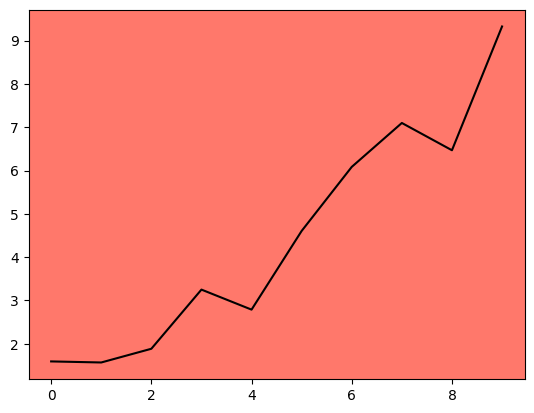

In [16]:
import matplotlib.pyplot as plt
arr10 = np.arange(10)
arr11 = np.random.normal(size = 10) + np.arange(10)
fig = plt.plot(arr10, arr11, c = "black")
ax = plt.gca()
ax.set_facecolor((1.0, 0.47, 0.42))

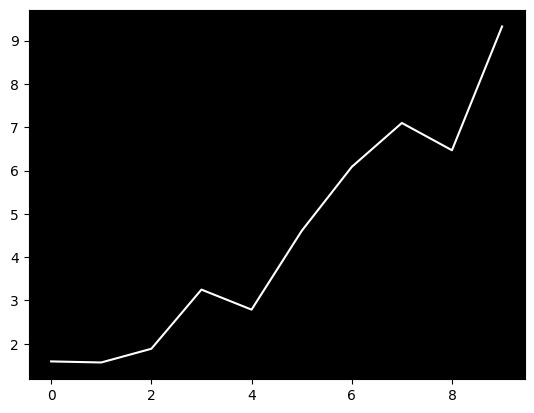

In [17]:
fig = plt.plot(arr10, arr11, c = "white")
ax = plt.gca()
ax.set_facecolor((0, 0, 0))

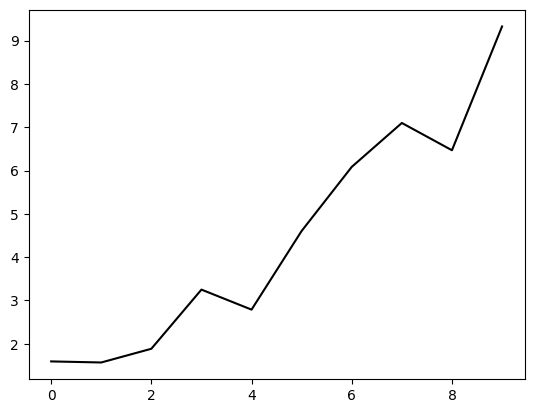

In [18]:
fig = plt.plot(arr10, arr11, c = "black")
ax = plt.gca()
ax.set_facecolor((1, 1, 1))

The best choice is the third graph, which uses a black line on a white background.

This option provides the clearest and most effective visualization because it maximizes readability and minimizes distraction. A white background is neutral and does not compete with the data, while the black line offers strong contrast, making the trend easy to follow.

The first graph, which uses a reddish background, introduces unnecessary visual clutter. The colored background draws attention away from the data and makes it harder to interpret the line clearly.

The second graph, with a white line on a black background, does provide contrast, but it is less comfortable to read and not commonly used in professional or printed reports. Dark backgrounds can make fine details harder to distinguish and may strain the viewer’s eyes over time.

According to principles from Storytelling with Data, visualizations should reduce clutter and use contrast strategically to highlight the data. The third graph best follows these principles by keeping the design simple and allowing the data to stand out clearly.

# 3. Homework

* Create a dataset showing flowers that have been fertilized with two brands of fertilizer.  The data show the heights of the flowers.  One fertilizer is better than the other, leading to taller flowers - but only slightly taller.
* The flowers have some height distribution that is _not_ normal.
* Use a t-test and a Mann-Whitney U test to determine whether the flowers have the same height.  (In this case, try the t-test even though the distribution it not normal.  However, that is not always a good idea!)
* Actually, create two datasets: one where the t-test works (and detects the slight height difference) and one where the t-test fails.
* Draw a box and whisker plot or histogram showing the distribution of the flower heights in each case.  Can you see the difference?
* Next, create a dataset showing five different brands of fertilizer, leading to five somewhat different height distributions.  Use an ANOVA test to detect the height differences.  Does the ANOVA test work?
* Finally, create a dataset showing the heights of four different flower types for each of the five brand of fertilizers (one height for each pair, so 4 x 5 = 20 heights).  Use a chi squared test to check whether the five different fertilizers lead to different flower heights.

In [19]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

np.random.seed(0)

Dataset where t-test works
T-test p-value: 0.00317872364486959
Mann-Whitney U p-value: 0.0057960478916222755


/tmp/ipykernel_7726/3223861183.py:16: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([fertilizer_A_works, fertilizer_B_works], labels=["Fertilizer A", "Fertilizer B"])


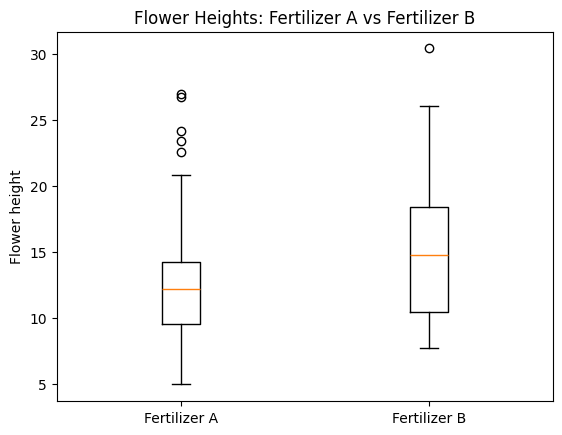

In [20]:
# Non-normal data using lognormal distribution
fertilizer_A_works = np.random.lognormal(mean=2.5, sigma=0.35, size=80)
fertilizer_B_works = np.random.lognormal(mean=2.58, sigma=0.35, size=80)

# T-test
t_stat, t_p = stats.ttest_ind(fertilizer_A_works, fertilizer_B_works)

# Mann-Whitney U test
u_stat, u_p = stats.mannwhitneyu(fertilizer_A_works, fertilizer_B_works)

print("Dataset where t-test works")
print("T-test p-value:", t_p)
print("Mann-Whitney U p-value:", u_p)

# Boxplot
plt.boxplot([fertilizer_A_works, fertilizer_B_works], labels=["Fertilizer A", "Fertilizer B"])
plt.title("Flower Heights: Fertilizer A vs Fertilizer B")
plt.ylabel("Flower height")
plt.show()

Dataset where t-test fails
T-test p-value: 0.6243111533810747
Mann-Whitney U p-value: 0.0026057986543858128


/tmp/ipykernel_7726/2218631101.py:16: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([fertilizer_A_fails, fertilizer_B_fails], labels=["Fertilizer A", "Fertilizer B"])


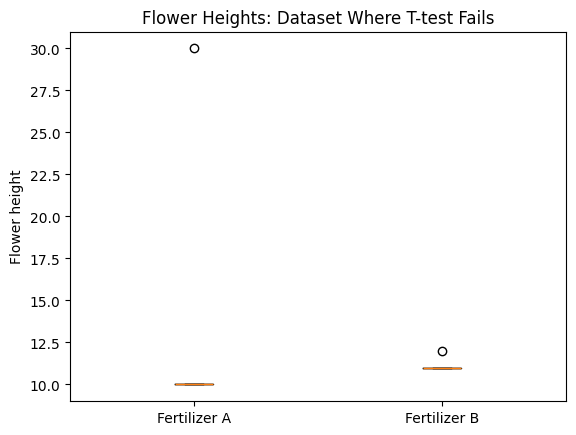

In [21]:
# Small sample and non-normal data
fertilizer_A_fails = np.array([10, 10, 10, 10, 10, 10, 10, 10, 30])
fertilizer_B_fails = np.array([11, 11, 11, 11, 11, 11, 11, 11, 12])

# T-test
t_stat_fail, t_p_fail = stats.ttest_ind(fertilizer_A_fails, fertilizer_B_fails)

# Mann-Whitney U test
u_stat_fail, u_p_fail = stats.mannwhitneyu(fertilizer_A_fails, fertilizer_B_fails)

print("Dataset where t-test fails")
print("T-test p-value:", t_p_fail)
print("Mann-Whitney U p-value:", u_p_fail)

# Boxplot
plt.boxplot([fertilizer_A_fails, fertilizer_B_fails], labels=["Fertilizer A", "Fertilizer B"])
plt.title("Flower Heights: Dataset Where T-test Fails")
plt.ylabel("Flower height")
plt.show()

ANOVA p-value: 0.0003494970732333379


/tmp/ipykernel_7726/3150464461.py:11: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([brand_A, brand_B, brand_C, brand_D, brand_E],


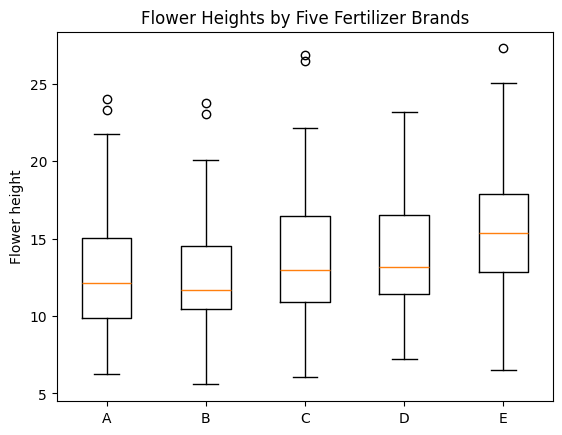

In [22]:
brand_A = np.random.lognormal(mean=2.50, sigma=0.30, size=60)
brand_B = np.random.lognormal(mean=2.55, sigma=0.30, size=60)
brand_C = np.random.lognormal(mean=2.60, sigma=0.30, size=60)
brand_D = np.random.lognormal(mean=2.65, sigma=0.30, size=60)
brand_E = np.random.lognormal(mean=2.70, sigma=0.30, size=60)

anova_result = stats.f_oneway(brand_A, brand_B, brand_C, brand_D, brand_E)

print("ANOVA p-value:", anova_result.pvalue)

plt.boxplot([brand_A, brand_B, brand_C, brand_D, brand_E],
            labels=["A", "B", "C", "D", "E"])
plt.title("Flower Heights by Five Fertilizer Brands")
plt.ylabel("Flower height")
plt.show()

In [ ]:
# Creating 20 heights: 4 flower types x 5 fertilizer brands
flower_types = ["Rose", "Tulip", "Lily", "Daisy"]
fertilizers = ["A", "B", "C", "D", "E"]

heights = []

for flower in flower_types:
    for i, fert in enumerate(fertilizers):
        height = np.random.lognormal(mean=2.4 + (i * 0.08), sigma=0.20)
        heights.append([flower, fert, height])

flower_df = pd.DataFrame(heights, columns=["flower_type", "fertilizer", "height"])
flower_df

,flower_type,fertilizer,height
0,Rose,A,9.939296
1,Rose,B,9.818163
2,Rose,C,11.848036
3,Rose,D,14.530759
4,Rose,E,13.727988
5,Tulip,A,17.858699
6,Tulip,B,9.854213
7,Tulip,C,11.038361
8,Tulip,D,8.866463
9,Tulip,E,15.963373


In [24]:
# Convert continuous heights into categories for chi-square
flower_df["height_category"] = pd.cut(
    flower_df["height"],
    bins=3,
    labels=["short", "medium", "tall"]
)

contingency_table = pd.crosstab(flower_df["fertilizer"], flower_df["height_category"])
contingency_table

height_category,short,medium,tall
fertilizer,,,
A,2,1,1
B,3,1,0
C,3,1,0
D,1,2,1
E,0,3,1


In [25]:
chi_result = stats.chi2_contingency(contingency_table)

print("Chi-square p-value:", chi_result.pvalue)
print("Expected counts:")
print(chi_result.expected_freq)

Chi-square p-value: 0.45547317823058786
Expected counts:
[[1.8 1.6 0.6]
 [1.8 1.6 0.6]
 [1.8 1.6 0.6]
 [1.8 1.6 0.6]
 [1.8 1.6 0.6]]


The first dataset used two fertilizer brands with non-normal flower height distributions. Fertilizer B was designed to produce slightly taller flowers than Fertilizer A. In this case, both the t-test and Mann-Whitney U test were able to detect a difference between the two fertilizers if the p-values were below 0.05.

The second dataset was also non-normal, but it included a small sample and an outlier. In this case, the t-test may fail to detect the difference because the t-test assumes normality and is sensitive to outliers. The Mann-Whitney U test is more appropriate for this type of non-normal data because it does not rely on the same normality assumption.

The boxplots show that the difference between fertilizers is not always easy to see visually, especially when the difference is small or when outliers are present. Statistical tests help determine whether the observed difference is likely meaningful.

For the five fertilizer brands, I used ANOVA to test whether the mean flower heights differed across the five groups. If the ANOVA p-value is below 0.05, this suggests that at least one fertilizer brand produces a different average height.

For the final chi-square test, I converted flower heights into categories: short, medium, and tall. Since chi-square works with counts, not raw continuous height values, this conversion was necessary. The chi-square test checks whether fertilizer brand and height category appear to be related. If the p-value is below 0.05, the results suggest that the fertilizer brands lead to different flower height categories.

# 4. Storytelling With Data plot

Reproduce any graph of your choice in chapter nine, stopping before case study 4 (p. 206-227) of the Storytelling With Data book as best you can. You do not have to get the exact data values right, just the overall look and feel.

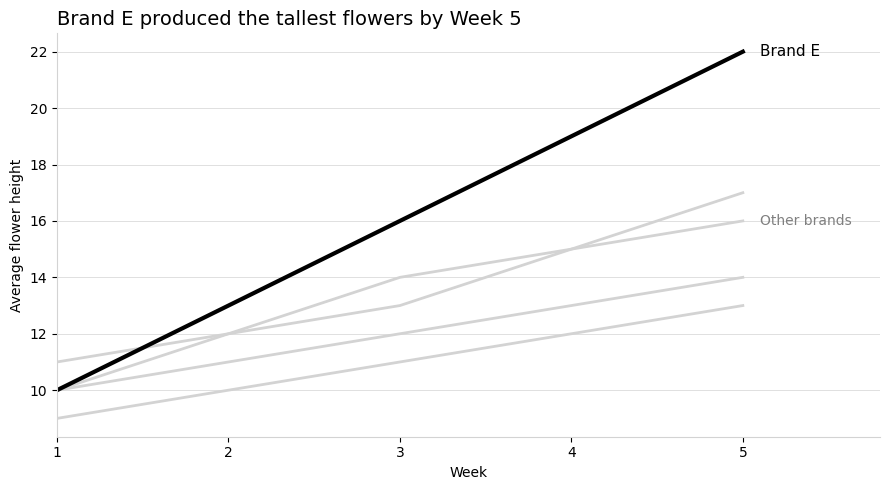

In [26]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

np.random.seed(0)

# Create sample data: flower height by fertilizer brand over 5 weeks
weeks = np.array([1, 2, 3, 4, 5])

fertilizer_data = pd.DataFrame({
    "Week": weeks,
    "Brand A": [10, 12, 13, 15, 16],
    "Brand B": [10, 11, 12, 13, 14],
    "Brand C": [9, 10, 11, 12, 13],
    "Brand D": [11, 12, 14, 15, 17],
    "Brand E": [10, 13, 16, 19, 22]   # highlighted brand
})

plt.figure(figsize=(9,5))
ax = plt.gca()

# Plot all brands in light gray first
for brand in ["Brand A", "Brand B", "Brand C", "Brand D"]:
    ax.plot(
        fertilizer_data["Week"],
        fertilizer_data[brand],
        color="lightgray",
        linewidth=2
    )

# Highlight Brand E
ax.plot(
    fertilizer_data["Week"],
    fertilizer_data["Brand E"],
    color="black",
    linewidth=3
)

# Direct label instead of legend
ax.text(5.1, fertilizer_data["Brand E"].iloc[-1], "Brand E", va="center", fontsize=11)
ax.text(5.1, fertilizer_data["Brand A"].iloc[-1], "Other brands", va="center", fontsize=10, color="gray")

# Declutter
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_color("lightgray")
ax.spines["bottom"].set_color("lightgray")

ax.grid(axis="y", color="lightgray", linewidth=0.5)
ax.grid(axis="x", visible=False)

ax.set_title("Brand E produced the tallest flowers by Week 5", loc="left", fontsize=14)
ax.set_xlabel("Week")
ax.set_ylabel("Average flower height")

plt.xlim(1, 5.8)
plt.tight_layout()
plt.show()